# Ego4D - Object Detection

Problem 1: Given a frame from an egocentric video, detect the target object in the vision query

e.g
-  "Target object": "Mr krips jar"
- Clip provided: Egocentric view of a person shopping in a grocery aisle


## Models
| Model | Architecture | Pretrained On |
|-------|-------------|---------------|
| YOLOv8s | Anchor-free, multi-scale CNN | COCO |
| Deformable DETR | Transformer + deformable attention | COCO |


**Evaluation protocol**
- Zero-shot: pretrained COCO weights, all predictions treated as class-agnostic

- Fine-tuned: trained on eGO4d response track frames

- Metrics: mAP@0.5, mAP@0.5:0.95

**Key findings from EDA informing the object detection problem formulation**

1. Median normalized object area within a frame: 1.9% of the frame

2. Frame resolution: 720 x 540 - 2x downsclaed from annotation space

3. 246,206 labeled detection frames across train and validation splits

4. Single class (object-agnostic detection) - Class-agnostic object detection (CA-OD) is a computer vision approach that localizes all objects within an image by drawing bounding boxes without identifying their specific categories (e.g., detecting "an object" rather than "a car" or "a dog"). This method improves generalization to unseen objects, reduces dependence on fully labeled datasets, and powers open-world detection

## Imports & Configurations

In [16]:
!pip install ultralytics transformers torch torchvision google-cloud-storage pycocotools tqdm --quiet

In [17]:
import json
import os
import shutil
import subprocess
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from tqdm.notebook import tqdm
from google.cloud import storage
from ultralytics import YOLO
from tqdm.notebook import tqdm

In [18]:
#GCS configuration
BUCKET_NAME = "egorecall-data"

#Local paths
DATA_DIR = Path("/content/egorecall_detection")
RESULTS_DIR = Path("/content/results/detection")

# DATA_DIR.mkdir(parents=True, exist_ok=True)
# RESULTS_DIR.mkdir(parents=True, exist_ok=True)


In [19]:
# Training configurations
YOLO_MODEL = "yolov8s.pt"
DETR_MODEL = "SenseTime/deformable-detr"
IMG_SIZE = 640 #YOLOv8 input size
YOLO_EPOCHS = 50
DETR_EPOCHS = 30
YOLO_BATCH_SIZE = 16
DETR_BATCH_SIZE = 4 #Deformable DETER is memory heavy
NUM_CLASSES = 1
CONF_THRESHOLD = 0.25 #0.5 - zero-shot inference confidence
IOU_THRESHOLD = 0.5

In [20]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")
if DEVICE == "cuda":
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
    print(f"VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Device: cuda
GPU    : Tesla T4
VRAM   : 15.6 GB


## GCS Authentication

In [6]:
from google.colab import auth
auth.authenticate_user()

gcs_client = storage.Client()
bucket = gcs_client.bucket(BUCKET_NAME)
print(f"Connected to gs://{BUCKET_NAME}")

Connected to gs://egorecall-data


## Sync Detection Frames from GCS to Local Colab

Estimated size is 19GB, which fits comfortably within Colab Pro's 200GB disk

In [7]:
result = subprocess.run(["df", "-h", "/content"], capture_output=True, text=True)
print(result.stdout)

Filesystem      Size  Used Avail Use% Mounted on
overlay         236G   43G  193G  19% /



In [8]:
# Create directories first
(DATA_DIR / "train" / "images").mkdir(parents=True, exist_ok=True)
(DATA_DIR / "val"   / "images").mkdir(parents=True, exist_ok=True)
(DATA_DIR / "train" / "labels").mkdir(parents=True, exist_ok=True)
(DATA_DIR / "val"   / "labels").mkdir(parents=True, exist_ok=True)
print("Directories created.")

Directories created.


## Uncomment and Run this section only once -> you should have at least 30GB of RAM on colab to run this

In [26]:
!gsutil cp gs://egorecall-data/processed/lbl_val.tar.gz   /tmp/
!tar -xzf /tmp/lbl_val.tar.gz   -C /content/egorecall_detection/val/labels/   --strip-components=2

In [25]:
!gsutil cp gs://egorecall-data/processed/det_val.tar.gz   /tmp/
!tar -xzf /tmp/det_val.tar.gz   -C /content/egorecall_detection/val/images/   --strip-components=2

In [24]:
!gsutil cp gs://egorecall-data/processed/lbl_train.tar /tmp/
!tar -xf /tmp/lbl_train.tar -C /content/egorecall_detection/train/labels/ --strip-components=2

In [27]:
!gsutil cp gs://egorecall-data/processed/det_train.tar /tmp/
!tar -xf /tmp/det_train.tar -C /content/egorecall_detection/train/images/ --strip-components=2

In [13]:
# Verify
train_imgs   = list((DATA_DIR / "train" / "images").rglob("*.jpg"))
val_imgs     = list((DATA_DIR / "val"   / "images").rglob("*.jpg"))
train_labels = list((DATA_DIR / "train" / "labels").rglob("*.txt"))
val_labels   = list((DATA_DIR / "val"   / "labels").rglob("*.txt"))

print(f"\nTrain images : {len(train_imgs):,}")
print(f"Train labels : {len(train_labels):,}")
print(f"Val images   : {len(val_imgs):,}")
print(f"Val labels   : {len(val_labels):,}")


Train images : 184,332
Train labels : 184,332
Val images   : 61,874
Val labels   : 61,874


## Flatten Structure

In [14]:
shutil.rmtree(DATA_DIR / "train" / "images_flat", ignore_errors=True)
shutil.rmtree(DATA_DIR / "train" / "labels_flat", ignore_errors=True)
shutil.rmtree(DATA_DIR / "val"   / "images_flat", ignore_errors=True)
shutil.rmtree(DATA_DIR / "val"   / "labels_flat", ignore_errors=True)
print("Cleaned up old symlinks.")

Cleaned up old symlinks.


In [15]:
def flatten_split(split):
    img_dir  = DATA_DIR / split / "images" / f"det_{split}"   # det_train or det_val
    lbl_dir  = DATA_DIR / split / "labels" / f"lbl_{split}"   # lbl_train or lbl_val
    flat_img = DATA_DIR / split / "images_flat"
    flat_lbl = DATA_DIR / split / "labels_flat"
    flat_img.mkdir(exist_ok=True)
    flat_lbl.mkdir(exist_ok=True)

    imgs = list(img_dir.rglob("*.jpg"))
    for img_path in tqdm(imgs, desc=f"Flattening {split}"):
        clip_uid = img_path.parent.name
        new_name = f"{clip_uid}_{img_path.name}"

        # Symlink image
        dst_img = flat_img / new_name
        if not dst_img.exists():
            dst_img.symlink_to(img_path.resolve())

        # Label — use original frame stem without clip_uid prefix
        lbl_path = lbl_dir / clip_uid / img_path.stem
        lbl_path = lbl_path.with_suffix(".txt")
        dst_lbl  = flat_lbl / f"{clip_uid}_{img_path.stem}.txt"
        if lbl_path.exists() and not dst_lbl.exists():
            dst_lbl.symlink_to(lbl_path.resolve())

    return len(imgs)

n_train = flatten_split("train")
n_val   = flatten_split("val")
print(f"Flattened: {n_train:,} train, {n_val:,} val")

flat_imgs = list((DATA_DIR / "train" / "images_flat").glob("*.jpg"))
flat_lbls = list((DATA_DIR / "train" / "labels_flat").glob("*.txt"))
print(f"Flat images : {len(flat_imgs):,}")
print(f"Flat labels : {len(flat_lbls):,}")

Flattening train:   0%|          | 0/184332 [00:00<?, ?it/s]

Flattening val:   0%|          | 0/61874 [00:00<?, ?it/s]

Flattened: 184,332 train, 61,874 val
Flat images : 184,332
Flat labels : 184,332


In [16]:
flat_imgs = list((DATA_DIR / "val" / "images_flat").glob("*.jpg"))
flat_lbls = list((DATA_DIR / "val" / "labels_flat").glob("*.txt"))
print(f"Flat images : {len(flat_imgs):,}")
print(f"Flat labels : {len(flat_lbls):,}")

Flat images : 61,874
Flat labels : 61,874


In [17]:
# Write YOLO dataset.yaml
dataset_yaml = DATA_DIR / "dataset.yaml"
yaml_content = f"""path: {DATA_DIR}
train: train/images_flat
val: val/images_flat

nc: 1
names: ['object']
"""
dataset_yaml.write_text(yaml_content)
print(dataset_yaml.read_text())

path: /content/egorecall_detection
train: train/images_flat
val: val/images_flat

nc: 1
names: ['object']



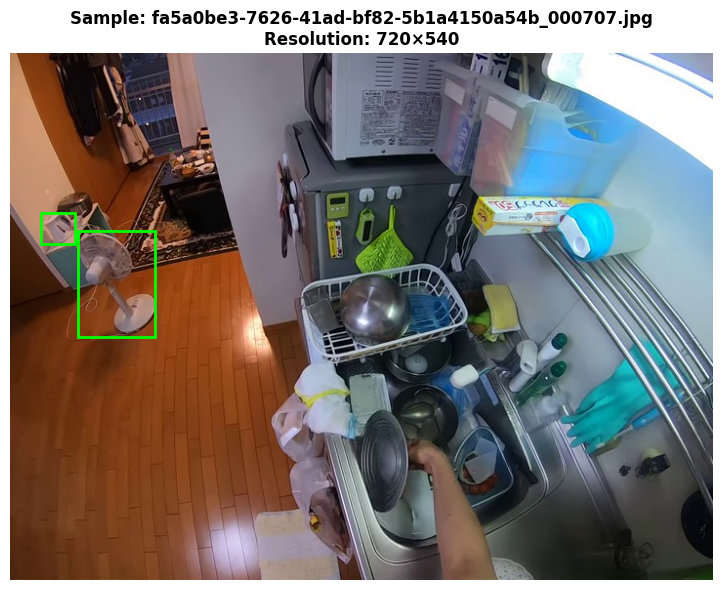

In [18]:
# Quick sanity check — visualize one sample with its label
sample_img  = list((DATA_DIR / "train" / "images_flat").glob("*.jpg"))[0]
sample_lbl  = (DATA_DIR / "train" / "labels_flat" / sample_img.stem).with_suffix(".txt")

img  = np.array(Image.open(sample_img))
h, w = img.shape[:2]

fig, ax = plt.subplots(1, 1, figsize=(8, 6))
ax.imshow(img)

if sample_lbl.exists():
    for line in sample_lbl.read_text().strip().split("\n"):
        cls, cx, cy, bw, bh = map(float, line.split())
        x1 = (cx - bw/2) * w
        y1 = (cy - bh/2) * h
        rect = patches.Rectangle(
            (x1, y1), bw*w, bh*h,
            linewidth=2, edgecolor="lime", facecolor="none"
        )
        ax.add_patch(rect)

ax.set_title(f"Sample: {sample_img.name}\nResolution: {w}×{h}", fontweight="bold")
ax.axis("off")
plt.tight_layout()
plt.show()

## YOLO

In [19]:
yolo_pretrained = YOLO(YOLO_MODEL)
print(f"Loaded: {YOLO_MODEL}")
print(f"COCO classes: {len(yolo_pretrained.names)}")

Loaded: yolov8s.pt
COCO classes: 80


In [20]:
def yolo_zero_shot_eval(model, img_dir, lbl_dir, conf=CONF_THRESHOLD,
                         iou_thresh=IOU_THRESHOLD, max_samples=2000):
    """
    Zero-shot evaluation:
    - Run pretrained COCO model on val frames
    - Merge all predicted boxes regardless of class (class-agnostic)
    - Compute IoU against ground truth boxes
    - Report mAP@0.5 and mAP@0.5:0.95
    """
    img_paths = list(img_dir.glob("*.jpg"))[:max_samples]

    all_pred_boxes  = []   # [x1,y1,x2,y2,conf]
    all_gt_boxes    = []   # [x1,y1,x2,y2]
    all_image_ids   = []

    for img_id, img_path in enumerate(tqdm(img_paths, desc="Zero-shot inference")):
        lbl_path = (lbl_dir / img_path.stem).with_suffix(".txt")
        if not lbl_path.exists():
            continue

        # Ground truth boxes
        img  = Image.open(img_path)
        w, h = img.size
        gt_boxes = []
        for line in lbl_path.read_text().strip().split("\n"):
            if not line.strip():
                continue
            _, cx, cy, bw, bh = map(float, line.split())
            x1 = (cx - bw/2) * w
            y1 = (cy - bh/2) * h
            x2 = (cx + bw/2) * w
            y2 = (cy + bh/2) * h
            gt_boxes.append([x1, y1, x2, y2])

        # Predictions — class-agnostic: keep all boxes above conf threshold
        results = model.predict(str(img_path), conf=conf, verbose=False)[0]
        pred_boxes = []
        if results.boxes is not None and len(results.boxes):
            for box in results.boxes:
                x1, y1, x2, y2 = box.xyxy[0].tolist()
                confidence      = box.conf[0].item()
                pred_boxes.append([x1, y1, x2, y2, confidence])

        all_gt_boxes.append(gt_boxes)
        all_pred_boxes.append(pred_boxes)
        all_image_ids.append(img_id)

    return compute_map(all_pred_boxes, all_gt_boxes)


def compute_iou(box1, box2):
    """Compute IoU between two [x1,y1,x2,y2] boxes."""
    xi1 = max(box1[0], box2[0])
    yi1 = max(box1[1], box2[1])
    xi2 = min(box1[2], box2[2])
    yi2 = min(box1[3], box2[3])
    inter = max(0, xi2-xi1) * max(0, yi2-yi1)
    area1 = (box1[2]-box1[0]) * (box1[3]-box1[1])
    area2 = (box2[2]-box2[0]) * (box2[3]-box2[1])
    union = area1 + area2 - inter
    return inter / union if union > 0 else 0.0


def compute_map(all_preds, all_gts, iou_thresholds=None):
    """
    Compute mAP@0.5 and mAP@0.5:0.95 for single-class detection.
    all_preds: list of [[x1,y1,x2,y2,conf], ...] per image
    all_gts  : list of [[x1,y1,x2,y2], ...] per image
    """
    if iou_thresholds is None:
        iou_thresholds = np.arange(0.5, 1.0, 0.05)

    aps = []
    for iou_thresh in iou_thresholds:
        tp_list, fp_list, conf_list = [], [], []
        n_gt = sum(len(g) for g in all_gts)

        for preds, gts in zip(all_preds, all_gts):
            if not preds:
                continue
            preds_sorted = sorted(preds, key=lambda x: x[4], reverse=True)
            matched = set()
            for pred in preds_sorted:
                conf_list.append(pred[4])
                best_iou, best_idx = 0, -1
                for j, gt in enumerate(gts):
                    iou = compute_iou(pred[:4], gt)
                    if iou > best_iou:
                        best_iou, best_idx = iou, j
                if best_iou >= iou_thresh and best_idx not in matched:
                    tp_list.append(1)
                    fp_list.append(0)
                    matched.add(best_idx)
                else:
                    tp_list.append(0)
                    fp_list.append(1)

        if not conf_list:
            aps.append(0.0)
            continue

        # Sort by confidence
        order = np.argsort(conf_list)[::-1]
        tp_cum = np.cumsum(np.array(tp_list)[order])
        fp_cum = np.cumsum(np.array(fp_list)[order])
        precision = tp_cum / (tp_cum + fp_cum + 1e-8)
        recall    = tp_cum / (n_gt + 1e-8)

        # Compute AP using 11-point interpolation
        ap = 0.0
        for thr in np.linspace(0, 1, 11):
            p = precision[recall >= thr].max() if (recall >= thr).any() else 0
            ap += p / 11
        aps.append(ap)

    return {
        "mAP@0.5"     : aps[0],
        "mAP@0.5:0.95": np.mean(aps),
        "per_iou_ap"  : dict(zip(iou_thresholds.round(2), aps))
    }

print("Evaluation functions defined.")

Evaluation functions defined.


In [21]:
# Run zero-shot evaluation
val_img_dir = DATA_DIR / "val" / "images_flat"
val_lbl_dir = DATA_DIR / "val" / "labels_flat"

print("Running YOLOv8s zero-shot evaluation...")
yolo_zeroshot_results = yolo_zero_shot_eval(
    yolo_pretrained, val_img_dir, val_lbl_dir
)

print("YOLOv8s Zero-Shot Results")
print(f"  mAP@0.5      : {yolo_zeroshot_results['mAP@0.5']:.4f}")
print(f"  mAP@0.5:0.95 : {yolo_zeroshot_results['mAP@0.5:0.95']:.4f}")

Running YOLOv8s zero-shot evaluation...


Zero-shot inference:   0%|          | 0/2000 [00:00<?, ?it/s]

YOLOv8s Zero-Shot Results
  mAP@0.5      : 0.0125
  mAP@0.5:0.95 : 0.0079


## YOLO Fine Tune

In [23]:
os.rename(DATA_DIR / "train" / "images_flat", DATA_DIR / "train" / "images_train_flat")
os.rename(DATA_DIR / "train" / "labels_flat", DATA_DIR / "train" / "labels_train_flat")
os.rename(DATA_DIR / "val"   / "images_flat", DATA_DIR / "val"   / "images_val_flat")
os.rename(DATA_DIR / "val"   / "labels_flat", DATA_DIR / "val"   / "labels_val_flat")

In [40]:
# Move labels into the images directory
# YOLO will find them right next to the images

train_lbl_dir = DATA_DIR / "train" / "labels_train_flat"
train_img_dir = DATA_DIR / "train" / "images_train_flat"

print("Moving train labels into images directory...")
for lbl in tqdm(list(train_lbl_dir.glob("*.txt"))):
    dst = train_img_dir / lbl.name
    if not dst.exists():
        os.rename(lbl, dst)

val_lbl_dir = DATA_DIR / "val" / "labels_val_flat"
val_img_dir = DATA_DIR / "val" / "images_val_flat"

print("Moving val labels into images directory...")
for lbl in tqdm(list(val_lbl_dir.glob("*.txt"))):
    dst = val_img_dir / lbl.name
    if not dst.exists():
        os.rename(lbl, dst)

print("Done.")

Moving train labels into images directory...


  0%|          | 0/184332 [00:00<?, ?it/s]

Moving val labels into images directory...


  0%|          | 0/61874 [00:00<?, ?it/s]

Done.


In [22]:
yaml_content = f"""path: {DATA_DIR}
train: train/images_train_flat
val: val/images_val_flat

nc: 1
names: ['object']
"""
dataset_yaml.write_text(yaml_content)

NameError: name 'dataset_yaml' is not defined

In [42]:
# import glob

# cache_files = glob.glob(str(DATA_DIR) + "/**/*.cache", recursive=True)
# for f in cache_files:
#     os.remove(f)
#     print(f"Deleted: {f}")

Deleted: /content/egorecall_detection/train/images_train_flat.cache
Deleted: /content/egorecall_detection/val/images_val_flat.cache


In [44]:
print(dataset_yaml.read_text())

path: /content/egorecall_detection
train: train/images_train_flat
val: val/images_val_flat

nc: 1
names: ['object']



In [29]:
# Check labels are now in the images directory
train_img_dir = DATA_DIR / "train" / "images_train_flat"
jpgs = list(train_img_dir.glob("*.jpg"))
txts = list(train_img_dir.glob("*.txt"))
print(f"Images in dir : {len(jpgs):,}")
print(f"Labels in dir : {len(txts):,}")

# Sample check
sample = txts[0]
print(f"\nSample label  : {sample.name}")
print(f"Content       : {sample.read_text().strip()}")

Images in dir : 184,332
Labels in dir : 184,332

Sample label  : f057b3fe-b29f-4796-b7ca-c8f46967fbf4_000320.txt
Content       : 0 0.523641 0.154990 0.027635 0.071229


In [31]:
# import shutil

# for i in range(1, 9):
#     path = Path(f"/content/results/detection/yolov8s_finetune-{i}")
#     if path.exists():
#         shutil.rmtree(path)
#         print(f"Removed: {path}")

# # Also remove the original incomplete one
# path = Path("/content/results/detection/yolov8s_finetune")
# if path.exists():
#     shutil.rmtree(path)
#     print(f"Removed: {path}")

In [ ]:
yolo_finetune = YOLO(YOLO_MODEL)

yolo_train_results = yolo_finetune.train(
    data    = str(dataset_yaml),
    epochs  = 10, #YOLO_EPOCHS,
    imgsz   = 320, #IMG_SIZE,
    batch   = YOLO_BATCH_SIZE,
    device  = DEVICE,
    project = str(RESULTS_DIR),
    name    = "yolov8s_finetune",
    # Training hyperparameters
    lr0     = 0.01,
    lrf     = 0.01,
    warmup_epochs = 3,
    # Augmentation — keep light given small objects
    hsv_h   = 0.015,
    hsv_s   = 0.7,
    hsv_v   = 0.4,
    flipud  = 0.0,    # egocentric video has consistent orientation
    fliplr  = 0.5,
    mosaic  = 1.0,
    # Logging
    plots   = True,
    verbose = True,
)

Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/egorecall_detection/dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=320, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8s_finetune, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask

In [1]:
# Evaluate fine-tuned YOLOv8s
best_yolo_path = RESULTS_DIR / "yolov8s_finetune" / "weights" / "best.pt"

yolo_finetuned = YOLO(str(best_yolo_path))

yolo_ft_results = yolo_zero_shot_eval(
    yolo_finetuned, val_img_dir, val_lbl_dir, conf=0.25
)

print("YOLOv8s Fine-Tuned Results")
print(f"  mAP@0.5      : {yolo_ft_results['mAP@0.5']:.4f}")
print(f"  mAP@0.5:0.95 : {yolo_ft_results['mAP@0.5:0.95']:.4f}")

NameError: name 'RESULTS_DIR' is not defined

In [ ]:
yolo_val_metrics = yolo_finetuned.val(data=str(dataset_yaml))
print(f"Built-in val mAP@0.5      : {yolo_val_metrics.box.map50:.4f}")
print(f"Built-in val mAP@0.5:0.95 : {yolo_val_metrics.box.map:.4f}")

##Deformable DETR — Zero-Shot Baseline

In [ ]:
from transformers import AutoImageProcessor, DeformableDetrForObjectDetection

# Load pretrained Deformable DETR
detr_processor = AutoImageProcessor.from_pretrained(DETR_MODEL)
detr_pretrained = DeformableDetrForObjectDetection.from_pretrained(DETR_MODEL)
detr_pretrained = detr_pretrained.to(DEVICE)
detr_pretrained.eval()

print(f"Loaded: {DETR_MODEL}")
print(f"COCO classes: {len(detr_pretrained.config.id2label)}")

In [ ]:
def detr_zero_shot_eval(model, processor, img_dir, lbl_dir,
                         conf=CONF_THRESHOLD, max_samples=2000):
    """
    Zero-shot eval for Deformable DETR.
    Class-agnostic: keep all predicted boxes above conf threshold.
    """
    img_paths = list(img_dir.glob("*.jpg"))[:max_samples]
    all_pred_boxes = []
    all_gt_boxes   = []

    model.eval()
    with torch.no_grad():
        for img_path in tqdm(img_paths, desc="DETR zero-shot inference"):
            lbl_path = (lbl_dir / img_path.stem).with_suffix(".txt")
            if not lbl_path.exists():
                continue

            img  = Image.open(img_path).convert("RGB")
            w, h = img.size

            # Ground truth
            gt_boxes = []
            for line in lbl_path.read_text().strip().split("\n"):
                if not line.strip():
                    continue
                _, cx, cy, bw, bh = map(float, line.split())
                gt_boxes.append([
                    (cx - bw/2) * w, (cy - bh/2) * h,
                    (cx + bw/2) * w, (cy + bh/2) * h
                ])

            # Inference
            inputs  = processor(images=img, return_tensors="pt").to(DEVICE)
            outputs = model(**inputs)
            target_sizes = torch.tensor([[h, w]]).to(DEVICE)
            results = processor.post_process_object_detection(
                outputs, threshold=conf, target_sizes=target_sizes
            )[0]

            pred_boxes = []
            for score, box in zip(results["scores"], results["boxes"]):
                x1, y1, x2, y2 = box.tolist()
                pred_boxes.append([x1, y1, x2, y2, score.item()])

            all_pred_boxes.append(pred_boxes)
            all_gt_boxes.append(gt_boxes)

    return compute_map(all_pred_boxes, all_gt_boxes)

print("DETR evaluation function defined.")

In [ ]:
print("Running Deformable DETR zero-shot evaluation...")
detr_zeroshot_results = detr_zero_shot_eval(
    detr_pretrained, detr_processor, val_img_dir, val_lbl_dir
)

print("\n── Deformable DETR Zero-Shot Results ───────────────")
print(f"  mAP@0.5      : {detr_zeroshot_results['mAP@0.5']:.4f}")
print(f"  mAP@0.5:0.95 : {detr_zeroshot_results['mAP@0.5:0.95']:.4f}")

## Deformable DETR — Fine-Tune

In [ ]:
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import OneCycleLR

class EgoRecallDetectionDataset(Dataset):
    """
    Reads flat YOLO-format images and labels.
    Converts to DETR-compatible format on the fly.
    """
    def __init__(self, img_dir, lbl_dir, processor):
        self.img_paths = sorted(img_dir.glob("*.jpg"))
        # Only keep images that have a corresponding label
        self.img_paths = [
            p for p in self.img_paths
            if (lbl_dir / p.stem).with_suffix(".txt").exists()
        ]
        self.lbl_dir   = lbl_dir
        self.processor = processor

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        img_path = self.img_paths[idx]
        lbl_path = (self.lbl_dir / img_path.stem).with_suffix(".txt")

        img  = Image.open(img_path).convert("RGB")
        w, h = img.size

        # Parse YOLO labels → COCO format [cx, cy, w, h] normalized
        boxes, labels = [], []
        for line in lbl_path.read_text().strip().split("\n"):
            if not line.strip():
                continue
            _, cx, cy, bw, bh = map(float, line.split())
            # DETR expects [cx, cy, w, h] in [0,1] — same as YOLO format
            boxes.append([cx, cy, bw, bh])
            labels.append(0)  # single class

        target = {
            "boxes" : torch.tensor(boxes,  dtype=torch.float32),
            "labels": torch.tensor(labels, dtype=torch.long),
            "image_id": torch.tensor([idx]),
            "orig_size": torch.tensor([h, w]),
        }

        encoding = self.processor(
            images=img, annotations=target, return_tensors="pt"
        )
        # Remove batch dim added by processor
        pixel_values = encoding["pixel_values"].squeeze(0)
        target       = encoding["labels"][0]

        return pixel_values, target


def collate_fn(batch):
    pixel_values = torch.stack([b[0] for b in batch])
    targets      = [b[1] for b in batch]
    return pixel_values, targets

print("Dataset class defined.")

In [ ]:
# ── Load fresh Deformable DETR for fine-tuning ────────────────────────────
# Replace classification head for single class + no-object
detr_finetune = DeformableDetrForObjectDetection.from_pretrained(
    DETR_MODEL,
    num_labels        = NUM_CLASSES,
    ignore_mismatched_sizes = True,
)
detr_finetune = detr_finetune.to(DEVICE)

# ── Datasets & dataloaders ────────────────────────────────────────────────
train_dataset = EgoRecallDetectionDataset(
    DATA_DIR / "train" / "images_flat",
    DATA_DIR / "train" / "labels_flat",
    detr_processor
)
val_dataset = EgoRecallDetectionDataset(
    DATA_DIR / "val" / "images_flat",
    DATA_DIR / "val" / "labels_flat",
    detr_processor
)

train_loader = DataLoader(
    train_dataset, batch_size=DETR_BATCH,
    shuffle=True, collate_fn=collate_fn,
    num_workers=2, pin_memory=True
)
val_loader = DataLoader(
    val_dataset, batch_size=DETR_BATCH,
    shuffle=False, collate_fn=collate_fn,
    num_workers=2, pin_memory=True
)

print(f"Train samples : {len(train_dataset):,}")
print(f"Val samples   : {len(val_dataset):,}")

In [ ]:
# ── Training loop ─────────────────────────────────────────────────────────
optimizer = AdamW(
    detr_finetune.parameters(),
    lr=1e-5,       # low LR for fine-tuning
    weight_decay=1e-4
)
scheduler = OneCycleLR(
    optimizer,
    max_lr=1e-4,
    steps_per_epoch=len(train_loader),
    epochs=DETR_EPOCHS
)

train_losses = []
val_losses   = []
best_val_loss = float("inf")
best_detr_path = RESULTS_DIR / "detr_best.pt"

for epoch in range(DETR_EPOCHS):
    # ── Train ──────────────────────────────────────────────────────────────
    detr_finetune.train()
    epoch_loss = 0.0
    for pixel_values, targets in tqdm(train_loader, desc=f"Epoch {epoch+1}/{DETR_EPOCHS}",
                                       leave=False):
        pixel_values = pixel_values.to(DEVICE)
        targets      = [{k: v.to(DEVICE) for k, v in t.items()} for t in targets]

        optimizer.zero_grad()
        outputs = detr_finetune(pixel_values=pixel_values, labels=targets)
        loss    = outputs.loss
        loss.backward()
        torch.nn.utils.clip_grad_norm_(detr_finetune.parameters(), 0.1)
        optimizer.step()
        scheduler.step()
        epoch_loss += loss.item()

    avg_train_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # ── Validate ───────────────────────────────────────────────────────────
    detr_finetune.eval()
    val_loss = 0.0
    with torch.no_grad():
        for pixel_values, targets in val_loader:
            pixel_values = pixel_values.to(DEVICE)
            targets      = [{k: v.to(DEVICE) for k, v in t.items()} for t in targets]
            outputs      = detr_finetune(pixel_values=pixel_values, labels=targets)
            val_loss    += outputs.loss.item()

    avg_val_loss = val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    print(f"Epoch {epoch+1:02d}/{DETR_EPOCHS} | "
          f"Train loss: {avg_train_loss:.4f} | "
          f"Val loss: {avg_val_loss:.4f}")

    # Save best
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(detr_finetune.state_dict(), best_detr_path)
        print(f"  → Best model saved (val_loss={best_val_loss:.4f})")

In [ ]:
# ── Plot training curves ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(train_losses, label="Train loss", color="#4C72B0")
ax.plot(val_losses,   label="Val loss",   color="#DD8452")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Deformable DETR Fine-Tuning", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig(RESULTS_DIR / "detr_training_curve.png", dpi=150)
plt.show()

In [ ]:
# ── Evaluate fine-tuned DETR ──────────────────────────────────────────────
detr_finetune.load_state_dict(torch.load(best_detr_path))
detr_finetune.eval()

detr_ft_results = detr_zero_shot_eval(
    detr_finetune, detr_processor, val_img_dir, val_lbl_dir, conf=0.25
)

print("\n── Deformable DETR Fine-Tuned Results ──────────────")
print(f"  mAP@0.5      : {detr_ft_results['mAP@0.5']:.4f}")
print(f"  mAP@0.5:0.95 : {detr_ft_results['mAP@0.5:0.95']:.4f}")
print("────────────────────────────────────────────────────")

## Results Comparison

In [ ]:
# ── Summary table ─────────────────────────────────────────────────────────
results = {
    "Model"         : ["YOLOv8s (zero-shot)", "YOLOv8s (fine-tuned)",
                       "Deformable DETR (zero-shot)", "Deformable DETR (fine-tuned)"],
    "mAP@0.5"       : [
        yolo_zeroshot_results["mAP@0.5"],
        yolo_ft_results["mAP@0.5"],
        detr_zeroshot_results["mAP@0.5"],
        detr_ft_results["mAP@0.5"],
    ],
    "mAP@0.5:0.95"  : [
        yolo_zeroshot_results["mAP@0.5:0.95"],
        yolo_ft_results["mAP@0.5:0.95"],
        detr_zeroshot_results["mAP@0.5:0.95"],
        detr_ft_results["mAP@0.5:0.95"],
    ],
}
results_df = pd.DataFrame(results)
results_df["mAP@0.5"]      = results_df["mAP@0.5"].round(4)
results_df["mAP@0.5:0.95"] = results_df["mAP@0.5:0.95"].round(4)
print(results_df.to_string(index=False))

In [ ]:
# ── Bar chart comparison ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors = ["#9ecae1", "#2171b5", "#fcae91", "#cb181d"]
models = ["YOLOv8s\nzero-shot", "YOLOv8s\nfine-tuned",
          "Def-DETR\nzero-shot", "Def-DETR\nfine-tuned"]
x = np.arange(len(models))

for ax, metric in zip(axes, ["mAP@0.5", "mAP@0.5:0.95"]):
    vals = results_df[metric].values
    bars = ax.bar(x, vals, color=colors, edgecolor="white", linewidth=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(models, fontsize=10)
    ax.set_ylabel(metric)
    ax.set_title(metric, fontweight="bold")
    ax.set_ylim(0, max(vals) * 1.2 + 0.05)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f"{val:.3f}", ha="center", va="bottom", fontsize=9)

plt.suptitle("EgoRecall — Detection Baseline Results", fontweight="bold", fontsize=13)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "detection_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# ── Qualitative: visualize predictions on sample val images ───────────────
sample_paths = list(val_img_dir.glob("*.jpg"))[:4]
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for i, img_path in enumerate(sample_paths):
    lbl_path = (val_lbl_dir / img_path.stem).with_suffix(".txt")
    img      = np.array(Image.open(img_path))
    h, w     = img.shape[:2]

    # Ground truth
    axes[0, i].imshow(img)
    if lbl_path.exists():
        for line in lbl_path.read_text().strip().split("\n"):
            if not line.strip(): continue
            _, cx, cy, bw, bh = map(float, line.split())
            rect = patches.Rectangle(
                ((cx-bw/2)*w, (cy-bh/2)*h), bw*w, bh*h,
                linewidth=2, edgecolor="lime", facecolor="none"
            )
            axes[0, i].add_patch(rect)
    axes[0, i].set_title("Ground Truth", fontsize=9)
    axes[0, i].axis("off")

    # YOLOv8 fine-tuned predictions
    axes[1, i].imshow(img)
    results = yolo_finetuned.predict(str(img_path), conf=0.25, verbose=False)[0]
    if results.boxes is not None:
        for box in results.boxes:
            x1, y1, x2, y2 = box.xyxy[0].tolist()
            conf = box.conf[0].item()
            rect = patches.Rectangle(
                (x1, y1), x2-x1, y2-y1,
                linewidth=2, edgecolor="red", facecolor="none"
            )
            axes[1, i].add_patch(rect)
            axes[1, i].text(x1, y1-2, f"{conf:.2f}",
                            color="red", fontsize=7, fontweight="bold")
    axes[1, i].set_title("YOLOv8s Fine-tuned", fontsize=9)
    axes[1, i].axis("off")

plt.suptitle("Qualitative Results — Val Samples", fontweight="bold")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "qualitative_predictions.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# ── Save results to GCS ───────────────────────────────────────────────────
results_df.to_parquet("/tmp/detection_results.parquet", index=False)
bucket.blob("processed/detection_results.parquet").upload_from_filename(
    "/tmp/detection_results.parquet"
)

# Save best model weights
bucket.blob("models/yolov8s_finetuned/best.pt").upload_from_filename(
    str(RESULTS_DIR / "yolov8s_finetune" / "weights" / "best.pt")
)
bucket.blob("models/detr_finetuned/best.pt").upload_from_filename(
    str(best_detr_path)
)

print("Results and model weights saved to GCS:")
print(f"  gs://{BUCKET_NAME}/processed/detection_results.parquet")
print(f"  gs://{BUCKET_NAME}/models/yolov8s_finetuned/best.pt")
print(f"  gs://{BUCKET_NAME}/models/detr_finetuned/best.pt")